# Hands-on script on Mode-based method and how to download and use Scholarly Migration Database data

### ============================
#### Author details ####
### ============================

### Script's author: Aliakbar Akbaritabar
### Version: 2024-11-05
### Tested: 2026-01-14
### Updated to 2026 data: 2026-06-29
### Email: akbaritabar@demogr.mpg.de
### Website: https://www.demogr.mpg.de/en/about_us_6113/staff_directory_1899/aliakbar_akbaritabar_4098/


During the hands-on session, we will use this additional notebook to discuss:
1) How mode-based method in identifying migration events work, 
2) How to download and use the scholarly migration database (SMD) data, 
3) What are the example research questions we can explore using the SMD data?

# How to use the mode-based method for migration?

# Toy example similar to Scopus data

In [1]:
import pandas as pd

# toy example to test

# a sample Pandas dataframe to use with DB

df = pd.DataFrame({
    'row_num': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    'author_id':[57215334932, 57215334932, 57215334932, 57215334932, 57215334932,57215334932, 57215334932, 57215334932,
                   57203865752, 57203865752, 57203865752, 57203865752, 57203865752,57203865752, 57203865752, 57203865752],
    'pubyear': [2002, 2000, 2001, 2003, 2004, 2010, 2010, 2011, 2000, 2002, 2005, 2007, 2007, 2007, 2009, 2010],
    'countrycode': ['USA', 'USA', 'DEU','DEU', 'GBR', 'USA', 'GBR', 'DEU', 'USA', 'USA', 'DEU','DEU', 'GBR', 'USA', 'GBR', 'DEU']
    })

# sort
df.sort_values(by=['author_id', 'pubyear', 'countrycode'], inplace=True)

In [2]:
df

,row_num,author_id,pubyear,countrycode
8,9,57203865752,2000,USA
9,10,57203865752,2002,USA
10,11,57203865752,2005,DEU
11,12,57203865752,2007,DEU
12,13,57203865752,2007,GBR
13,14,57203865752,2007,USA
14,15,57203865752,2009,GBR
15,16,57203865752,2010,DEU
1,2,57215334932,2000,USA
2,3,57215334932,2001,DEU


In [3]:
dfallgrouped = df.groupby(['author_id','pubyear']).agg(
    countrycodecombinedmode=pd.NamedAgg(column='countrycode', aggfunc=pd.Series.mode)
    )

dfallgrouped.sort_values(by=["author_id","pubyear"],inplace=True)


In [4]:
dfallgrouped

countrycodecombinedmode
author_id   pubyear                        
57203865752 2000                        USA
            2002                        USA
            2005                        DEU
            2007            [DEU, GBR, USA]
            2009                        GBR
            2010                        DEU
57215334932 2000                        USA
            2001                        DEU
            2002                        USA
            2003                        DEU
            2004                        GBR
            2010                 [GBR, USA]
            2011                        DEU

# How to download and use Scholarly Migration Database

In [5]:
import pandas as pd

In [6]:
import plotnine as gg

In [7]:
# copy data download URLs from "https://www.scholarlymigration.org/data.html"

# 2026 version of the data
country_data = pd.read_parquet(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_input/2026_V2/scopus_scholarlymigration_country_gender_and_field.parquet"
)

flow_data = pd.read_parquet(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_input/2026_V2/scopus_scholarlymigration_country_flows_gender_and_field.parquet"
)


In [8]:
# OpenAlex
op_country = pd.read_parquet(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_input/2026_V2/openalex_scholarlymigration_country_gender_and_field.parquet"
)
op_flow = pd.read_parquet(
    "https://github.com/MPIDR/Global-flows-and-rates-of-international-migration-of-scholars/raw/refs/heads/master/data_input/2026_V2/openalex_scholarlymigration_country_flows_gender_and_field.parquet"
)

### Note on 2026 version of the Scholarly Migration Datatabase (SMD 2.0)
In addition to country level bilateral flows and rates, it now includes subnational level data (which I am not using here in this example, but you are welcome to test on your own) and disaggregation of rates and flows by gender and field!

In [9]:
who_ls DataFrame

['country_data', 'df', 'dfallgrouped', 'flow_data', 'op_country', 'op_flow']

In [10]:
country_data

,year,area,iso2code,iso3code,countryname,gender,field,padded_population_of_researchers,number_of_inmigrations,number_of_outmigrations,netmigration,outmigrationrate,inmigrationrate,netmigrationrate
0,1995,ABW,AW,ABW,Aruba,all,AgEnNat,0,0,0,0,NaN,NaN,NaN
1,1995,ABW,AW,ABW,Aruba,all,all,0,0,0,0,NaN,NaN,NaN
2,1995,ABW,AW,ABW,Aruba,u,AgEnNat,0,0,0,0,NaN,NaN,NaN
3,1995,ABW,AW,ABW,Aruba,u,all,0,0,0,0,NaN,NaN,NaN
4,1996,ABW,AW,ABW,Aruba,all,AgEnNat,1,0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99475,2024,ZWE,ZW,ZWE,Zimbabwe,m,all,0,19,28,-9,NaN,NaN,NaN
99476,2024,ZWE,ZW,ZWE,Zimbabwe,u,AgEnNat,0,4,10,-6,NaN,NaN,NaN
99477,2024,ZWE,ZW,ZWE,Zimbabwe,u,HumSS,0,2,6,-4,NaN,NaN,NaN
99478,2024,ZWE,ZW,ZWE,Zimbabwe,u,MhS,0,3,5,-2,NaN,NaN,NaN


In [11]:
flow_data

,area_from,area_to,year,gender,field,n_migrations
0,ABW,ATG,2021,all,MhS,1
1,ABW,ATG,2021,all,all,1
2,ABW,ATG,2021,m,MhS,1
3,ABW,ATG,2021,m,all,1
4,ABW,BEL,2016,all,MhS,1
...,...,...,...,...,...,...
861108,ZWE,ZMB,2022,all,all,2
861109,ZWE,ZMB,2022,f,AgEnNat,1
861110,ZWE,ZMB,2022,f,all,1
861111,ZWE,ZMB,2022,m,MhS,1


In [12]:
op_country

,year,area,iso2code,iso3code,countryname,gender,field,padded_population_of_researchers,number_of_inmigrations,number_of_outmigrations,netmigration,outmigrationrate,inmigrationrate,netmigrationrate
0,1996,ABW,AW,ABW,Aruba,all,HumSS,1,0,0,0,0.0,0.0,0.0
1,1996,ABW,AW,ABW,Aruba,all,all,1,0,0,0,0.0,0.0,0.0
2,1996,ABW,AW,ABW,Aruba,u,HumSS,1,0,0,0,0.0,0.0,0.0
3,1996,ABW,AW,ABW,Aruba,u,all,1,0,0,0,0.0,0.0,0.0
4,1997,ABW,AW,ABW,Aruba,all,HumSS,1,0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107855,2025,ZWE,ZW,ZWE,Zimbabwe,m,all,0,73,68,5,NaN,NaN,NaN
107856,2025,ZWE,ZW,ZWE,Zimbabwe,u,AgEnNat,0,20,11,9,NaN,NaN,NaN
107857,2025,ZWE,ZW,ZWE,Zimbabwe,u,HumSS,0,5,15,-10,NaN,NaN,NaN
107858,2025,ZWE,ZW,ZWE,Zimbabwe,u,MhS,0,7,7,0,NaN,NaN,NaN


In [13]:
op_flow

,area_from,area_to,year,gender,field,n_migrations
0,ABW,AUS,2009,all,AgEnNat,1
1,ABW,AUS,2009,all,all,1
2,ABW,AUS,2009,m,AgEnNat,1
3,ABW,AUS,2009,m,all,1
4,ABW,BRA,2013,all,AgEnNat,1
...,...,...,...,...,...,...
1482433,ZWE,ZMB,2022,f,AgEnNat,1
1482434,ZWE,ZMB,2022,f,all,1
1482435,ZWE,ZMB,2022,m,AgEnNat,1
1482436,ZWE,ZMB,2022,m,HumSS,1


In [14]:
country_data.groupby('area')['number_of_inmigrations'].sum().reset_index().rename(columns={'number_of_inmigrations':'sum_inMig'}).sort_values(by='sum_inMig', ascending=False).head(n=20)

,area,sum_inMig
225,USA,1856552
76,GBR,752968
56,DEU,587704
41,CHN,514078
37,CAN,431392
72,FRA,423730
13,AUS,306852
39,CHE,284732
109,JPN,243090
65,ESP,227572


In [15]:
country_data.loc[100]

year                                 2007
area                                  ABW
iso2code                               AW
iso3code                              ABW
countryname                         Aruba
gender                                  f
field                                 all
padded_population_of_researchers        1
number_of_inmigrations                  0
number_of_outmigrations                 0
netmigration                            0
outmigrationrate                      0.0
inmigrationrate                       0.0
netmigrationrate                      0.0
Name: 100, dtype: object

# Example research questions 1: Travel ban's effect

In 2017, USA imposed a travel ban on 7 country nationals entrance. Here we briefly look if using the SMD flow data, we can ask:

1. are the flows from these countries to the USA affected by the travel ban?
2. are there alternative countries who might have become the new destination of scholars from those seven countries and experience an increased flow?

## Related literature to check
If you are interested to know more about this topic, check the following references:

- Chinchilla-Rodríguez, Z., Bu, Y., Robinson-García, N., Costas, R., & Sugimoto, C. R. (2018). Travel bans and scientific mobility: Utility of asymmetry and affinity indexes to inform science policy. Scientometrics, 116(1), 569–590. https://doi.org/10.1007/s11192-018-2738-2
- Morello, L., & Reardon, S. (2017). Meet the scientists affected by Trump’s immigration ban. Nature, 542(7639), 13–14. https://doi.org/10.1038/nature.2017.21389
- Stone, R. (2018). Science in Iran languishes after Trump re-imposes sanctions. Science. https://doi.org/10.1126/science.aav2811

In [16]:
flow_data.area_from.unique()

array(['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'AND', 'ARE', 'ARG', 'ARM',
       'ASM', 'ATA', 'ATF', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL',
       'BEN', 'BES', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR',
       'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BVT', 'BWA',
       'CAF', 'CAN', 'CCK', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD',
       'COG', 'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CUW', 'CXR', 'CYM',
       'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU',
       'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'EUE', 'FIN', 'FJI', 'FLK',
       'FRA', 'FRO', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIB', 'GIN',
       'GLP', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL', 'GTM', 'GUF',
       'GUM', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND',
       'IOT', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR',
       'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT',
       'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU',
       'LUX', 'LVA',

In [17]:
# adding CHN, UKR, RUS in addition to see
banned_countries = ['IRN', 'IRQ', 'SYR', 'LBY', 'SOM', 'SDN', 'YEM', 'CHN', 'UKR', 'RUS']
destination_countries = ['USA', 'DEU', 'GBR', 'CAN', 'NLD', 'AUS']
ban2usa = flow_data[
    (flow_data.area_from.isin(banned_countries))
    & (flow_data.area_to.isin(destination_countries))
    # for now, filter to only all genders and fields
    & (flow_data.gender.isin(["all"]))
    & (flow_data.field.isin(["all"]))
]
op_ban2usa = op_flow[
    (op_flow.area_from.isin(banned_countries))
    & (op_flow.area_to.isin(destination_countries))
    # for now, filter to only all genders and fields
    & (op_flow.gender.isin(["all"]))
    & (op_flow.field.isin(["all"]))
]

In [18]:
ban2usa.year.unique()

array([1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022])

In [19]:
op_ban2usa.shape

(1160, 6)

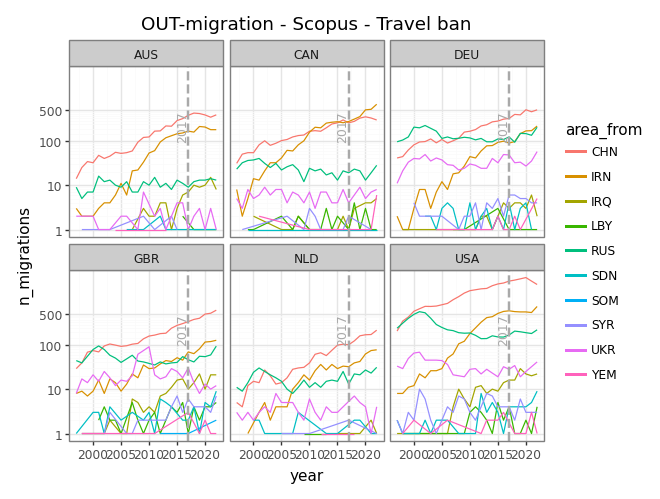

In [20]:
# Scopus
(
    gg.ggplot(ban2usa, gg.aes(x="year", y="n_migrations", color="area_from"))
    + gg.geom_line()
    + gg.geom_vline(
        gg.aes(xintercept=2017), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2016,
        y=500,
        label="2017",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.scale_y_log10(breaks=[1, 10, 100, 500])
    + gg.facet_wrap("area_to")
    + gg.labs(title="OUT-migration - Scopus - Travel ban")
    + gg.theme_bw()
)

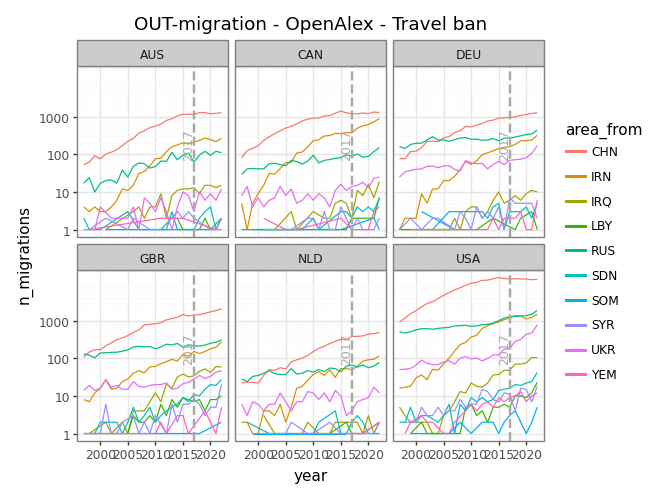

In [21]:
# OpenAlex
(
    gg.ggplot(op_ban2usa, gg.aes(x="year", y="n_migrations", color='area_from'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.scale_y_log10(breaks=[1, 10, 100, 1000])
    + gg.facet_wrap('area_to')
    + gg.labs(title='OUT-migration - OpenAlex - Travel ban')
    + gg.theme_bw()
)

# Example research questions 2: recent "INmigration" and "OUTmigration" to/from Ukraine and Russia

In this second example, we want to use the SMD data and see if in-migartion or out-mgration to/from Ukraine and Russia have changed during the past years which potentially could be associated with the ongoing conflict.

## Related literature to check
If you are interested to know more about this topic, check the following references:

- Wachs, J. (2023). Digital traces of brain drain: Developers during the Russian invasion of Ukraine. EPJ Data Science, 12(1), Article 1. https://doi.org/10.1140/epjds/s13688-023-00389-3
- Ganguli, I., & Waldinger, F. (2024). War and Science in Ukraine. Entrepreneurship and Innovation Policy and the Economy, 3, 165–188. https://doi.org/10.1086/727771
- Leasure, D. R., Kashyap, R., Rampazzo, F., Dooley, C. A., Elbers, B., Bondarenko, M., Verhagen, M., Frey, A., Yan, J., Akimova, E. T., Fatehkia, M., Trigwell, R., Tatem, A. J., Weber, I., & Mills, M. C. (2023). Nowcasting Daily Population Displacement in Ukraine through Social Media Advertising Data. Population and Development Review, n/a(n/a). https://doi.org/10.1111/padr.12558


# "OUTmigration" from Ukraine and Russia

In [22]:
selected_countries = ['UKR', 'RUS']
ukrrus_out = flow_data[(flow_data.area_from.isin(selected_countries))]
op_ukrrus_out = op_flow[(op_flow.area_from.isin(selected_countries))]

In [23]:
ukrrus_out.describe()

,year,n_migrations
count,18620.000000,18620.000000
mean,2010.829431,7.219119
std,7.682255,20.553933
min,1997.000000,1.000000
25%,2004.000000,1.000000
50%,2012.000000,2.000000
75%,2018.000000,6.000000
max,2022.000000,556.000000


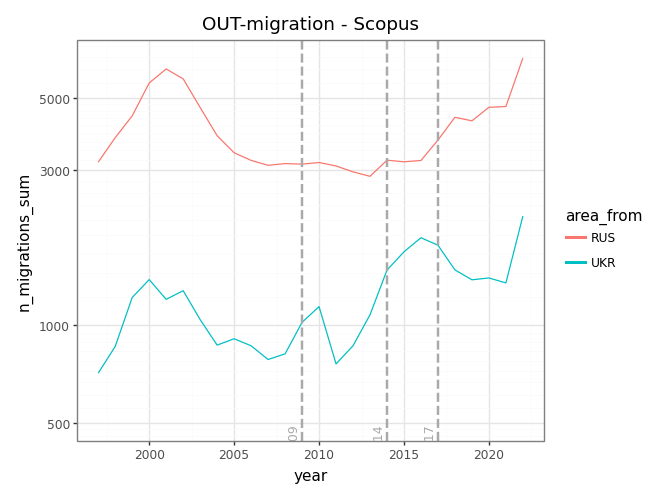

In [24]:
# Scopus
(
    gg.ggplot(
        (
            ukrrus_out.groupby(["year", "area_from"])
            .n_migrations.sum()
            .reset_index()
            .rename(columns={"n_migrations": "n_migrations_sum"})
        ),
        gg.aes(x="year", y="n_migrations_sum", color="area_from"),
    )
    + gg.geom_line()
    + gg.geom_vline(
        gg.aes(xintercept=2017), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2016.5,
        y=500,
        label="2017",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.geom_vline(
        gg.aes(xintercept=2014), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2013.5,
        y=500,
        label="2014",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.geom_vline(
        gg.aes(xintercept=2009), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2008.5,
        y=500,
        label="2009",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.labs(title="OUT-migration - Scopus")
    + gg.theme_bw()
    + gg.scale_y_log10()
)

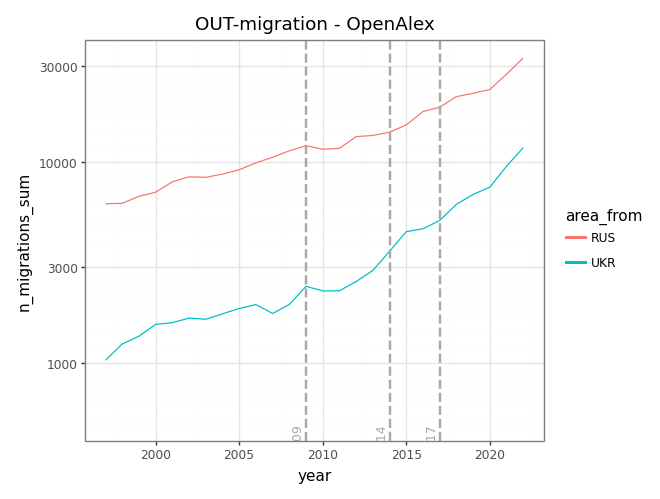

In [25]:
# OpenAlex
(
    gg.ggplot((
        op_ukrrus_out
        .groupby(['year', 'area_from'])
        .n_migrations.sum()
        .reset_index()
        .rename(columns={'n_migrations':'n_migrations_sum'})
    ), gg.aes(x="year", y="n_migrations_sum", color='area_from'))
    + gg.geom_line()
    + gg.geom_vline(gg.aes(xintercept=2017), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2016.5, y=500, label="2017", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2014), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2013.5, y=500, label="2014", size=9, color="darkgray", va="top", angle=90)
    + gg.geom_vline(gg.aes(xintercept=2009), color='darkgray', linetype='dashed', size=1)
    + gg.annotate("text", x=2008.5, y=500, label="2009", size=9, color="darkgray", va="top", angle=90)
    + gg.labs(title='OUT-migration - OpenAlex')
    + gg.theme_bw()
    + gg.scale_y_log10()
)

# "INmigration" to Ukraine and Russia

In [26]:
selected_countries = ['UKR', 'RUS']
ukrrus_in = flow_data[(flow_data.area_to.isin(selected_countries))]
op_ukrrus_in = op_flow[(op_flow.area_to.isin(selected_countries))]

In [27]:
ukrrus_in.describe()

,year,n_migrations
count,16200.000000,16200.00000
mean,2010.870123,5.86037
std,7.639061,14.73453
min,1997.000000,1.00000
25%,2004.000000,1.00000
50%,2012.000000,2.00000
75%,2018.000000,5.00000
max,2022.000000,305.00000


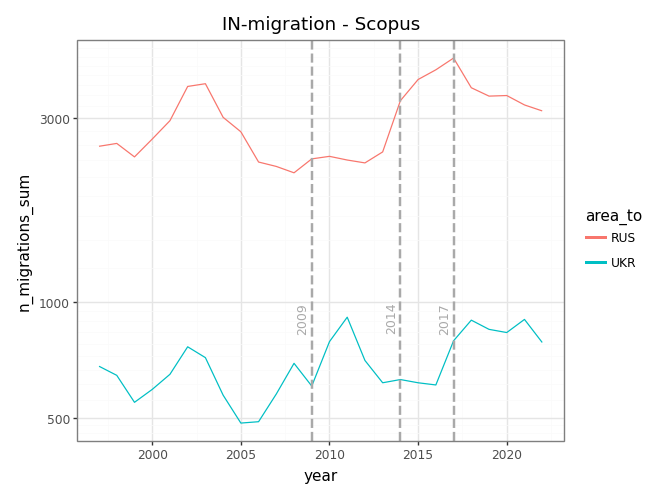

In [28]:
# Scopus
(
    gg.ggplot(
        (
            ukrrus_in.groupby(["year", "area_to"])
            .n_migrations.sum()
            .reset_index()
            .rename(columns={"n_migrations": "n_migrations_sum"})
        ),
        gg.aes(x="year", y="n_migrations_sum", color="area_to"),
    )
    + gg.geom_line()
    + gg.geom_vline(
        gg.aes(xintercept=2017), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2016.5,
        y=1000,
        label="2017",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.geom_vline(
        gg.aes(xintercept=2014), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2013.5,
        y=1000,
        label="2014",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.geom_vline(
        gg.aes(xintercept=2009), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2008.5,
        y=1000,
        label="2009",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.labs(title="IN-migration - Scopus")
    + gg.theme_bw()
    + gg.scale_y_log10()
)

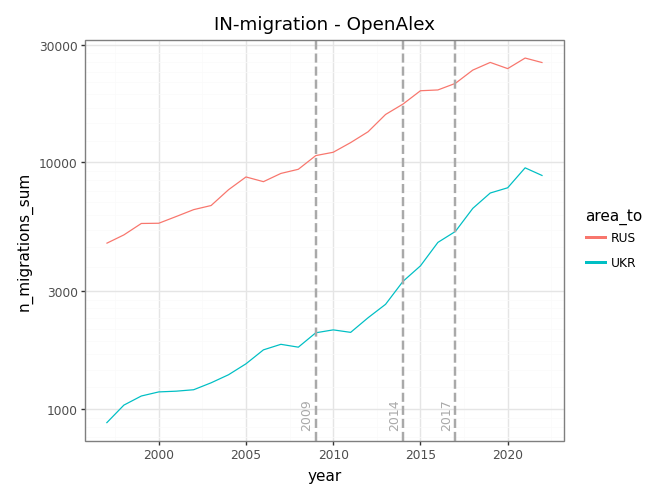

In [30]:
# OpenAlex
(
    gg.ggplot(
        (
            op_ukrrus_in.groupby(["year", "area_to"])
            .n_migrations.sum()
            .reset_index()
            .rename(columns={"n_migrations": "n_migrations_sum"})
        ),
        gg.aes(x="year", y="n_migrations_sum", color="area_to"),
    )
    + gg.geom_line()
    + gg.geom_vline(
        gg.aes(xintercept=2017), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2016.5,
        y=1100,
        label="2017",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.geom_vline(
        gg.aes(xintercept=2014), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2013.5,
        y=1100,
        label="2014",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.geom_vline(
        gg.aes(xintercept=2009), color="darkgray", linetype="dashed", size=1
    )
    + gg.annotate(
        "text",
        x=2008.5,
        y=1100,
        label="2009",
        size=9,
        color="darkgray",
        va="top",
        angle=90,
    )
    + gg.labs(title="IN-migration - OpenAlex")
    + gg.theme_bw()
    + gg.scale_y_log10()
)